In [3]:
import numpy as np 
import pandas as pd 
import os 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("Medicaldataset.csv")
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


Pre processing ~ missing values

In [5]:
df.info()
print("=========================================")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB
Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin        

In [6]:
print(df.describe())

               Age       Gender   Heart rate  Systolic blood pressure  \
count  1319.000000  1319.000000  1319.000000              1319.000000   
mean     56.191812     0.659591    78.336619               127.170584   
std      13.647315     0.474027    51.630270                26.122720   
min      14.000000     0.000000    20.000000                42.000000   
25%      47.000000     0.000000    64.000000               110.000000   
50%      58.000000     1.000000    74.000000               124.000000   
75%      65.000000     1.000000    85.000000               143.000000   
max     103.000000     1.000000  1111.000000               223.000000   

       Diastolic blood pressure  Blood sugar        CK-MB     Troponin  
count               1319.000000  1319.000000  1319.000000  1319.000000  
mean                  72.269143   146.634344    15.274306     0.360942  
std                   14.033924    74.923045    46.327083     1.154568  
min                   38.000000    35.000000     0

Removing Outliers~~ using IQR and z- score

In [7]:
numerical_columns = ['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']
df.loc[:, numerical_columns] = df[numerical_columns].clip(lower=0)
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
    
    z_scores = np.abs(stats.zscore(df[col]))
    zscore_mask = z_scores <= 3
    df = df[iqr_mask | zscore_mask]

Line Chart ~~ Visualization

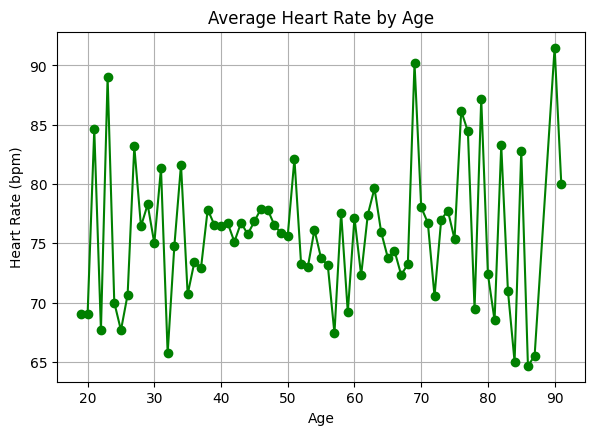

In [8]:
plt.figure(figsize=(15, 10))  
plt.subplot(2, 2, 1)
avg_heart_rate_by_age = df.groupby('Age')['Heart rate'].mean()
avg_heart_rate_by_age.plot(kind='line', marker='o', color='green')
plt.title('Average Heart Rate by Age')
plt.xlabel('Age')
plt.ylabel('Heart Rate (bpm)')
plt.grid(True)

Bar chart

(array([0, 1]), [Text(0, 0, 'negative'), Text(1, 0, 'positive')])

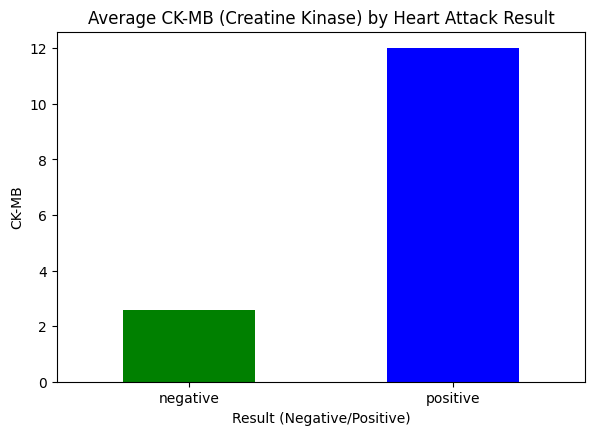

In [10]:
plt.figure(figsize=(15, 10))  
plt.subplot(2, 2, 2)
avg_CK_MB_by_result = df.groupby('Result')['CK-MB'].mean()
avg_CK_MB_by_result.plot(kind='bar', color=['green', 'blue'])
plt.title('Average CK-MB (Creatine Kinase) by Heart Attack Result')
plt.xlabel('Result (Negative/Positive)')
plt.ylabel('CK-MB')
plt.xticks(rotation=0)

Histogram

Text(0, 0.5, 'Frequency')

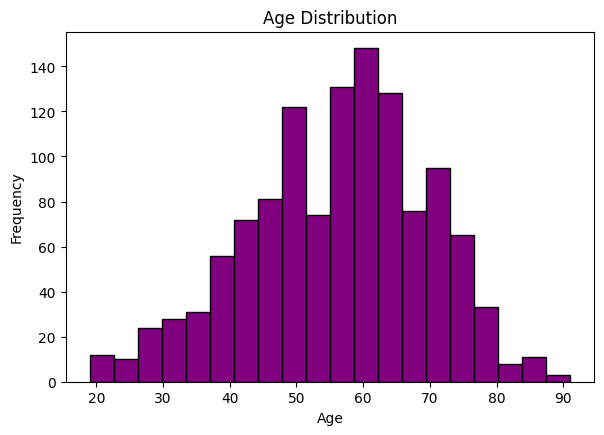

In [12]:
plt.figure(figsize=(15, 10))  
plt.subplot(2, 2, 3)
plt.hist(df['Age'], bins=20, color='purple', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

Pie Chart

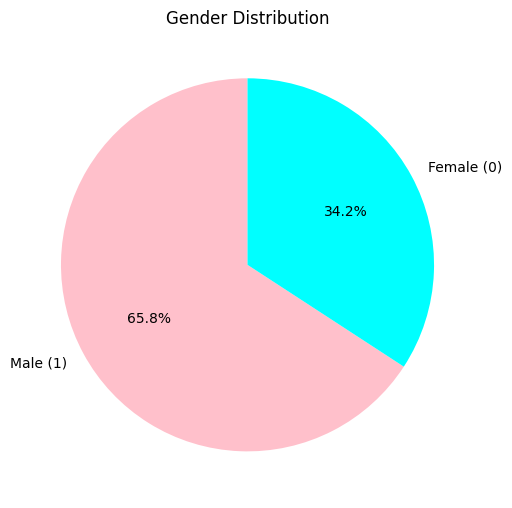

In [14]:
plt.figure(figsize=(15, 10))  
plt.subplot(2, 2, 4)
gender_counts = df['Gender'].value_counts()
labels = ['Female (0)', 'Male (1)']if gender_counts.index.tolist() == [0, 1] else ['Male (1)', 'Female (0)']
plt.pie(gender_counts, labels=labels, colors=['pink', 'cyan'], autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')

plt.tight_layout()
plt.show()

Heat Map

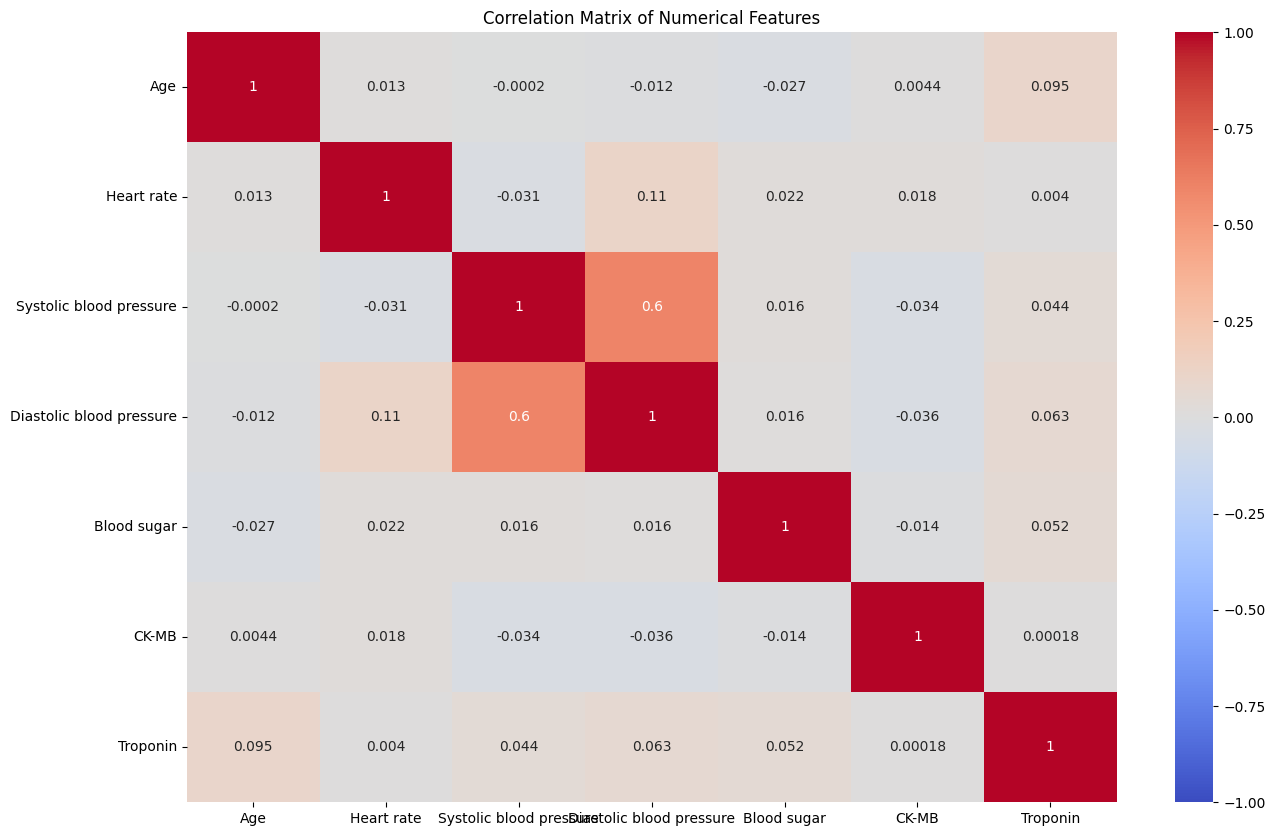

In [16]:
plt.figure(figsize=(15, 10))  
corr_matrix = df[numerical_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=0)
plt.show()

Label Encoding ~ change the string columns to int

In [17]:
le = LabelEncoder()
df.loc[:, 'Result'] = le.fit_transform(df['Result'].astype(str))
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1312,48,1,84,118,68,96.0,5.33,0.006,0
1313,86,0,40,179,68,147.0,5.22,0.011,0
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1


Split Train Test

In [18]:
X = df.drop('Result', axis=1) # Features
y = df['Result'] #Target 
X.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
0,64,1,66,160,83,160.0,1.80,0.012
1,21,1,94,98,46,296.0,6.75,1.060
2,55,1,64,160,77,270.0,1.99,0.003
3,64,1,70,120,55,270.0,13.87,0.122
4,55,1,64,112,65,300.0,1.08,0.003


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=40)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Prediction

In [21]:
y_test = y_test.astype('int64')  
y_train = y_train.astype('int64') 

In [23]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred = dt.predict(X_test_scaled)
dt_accuracy=accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9834710743801653


In [27]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
rf_accuracy=accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.987603305785124


In [24]:
from sklearn import svm
clf = svm.SVC(kernel='linear')
clf.fit(X_train_scaled, y_train)

y_pred_svm = clf.predict(X_test_scaled)
svm_accuracy=accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8429752066115702


In [25]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log_reg = log_reg.predict(X_test_scaled)
lr_accuracy=accuracy_score(y_test, y_pred_log_reg)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8264462809917356
